# Smart Greenhouse Climate Control System

Acest proiect implementează un sistem inteligent pentru controlul unei sere.

**Componente principale:**
1. **Preprocesarea datelor:** Curățare, Denoising (medii mobile), Normalizare și PCA.
2. **Analiză Exploratorie:** Vizualizarea seriilor de timp și a corelațiilor.
3. **Modele Predictive:** Regresie Liniară, Polinomială și Random Forest pentru predicția temperaturii, umidității și a nivelului apei.
4. **Optimizare Resurse:** Algoritm pentru minimizarea consumului de apă și nutrienți.
5. **Control Actuatori:** Logică de decizie pentru ventilatoare și pompe.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
import warnings
import os

# Configurări globale
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Creare directoare necesare
os.makedirs('models', exist_ok=True)
os.makedirs('visualizations', exist_ok=True)

print("Biblioteci importate și mediu configurat.")

Biblioteci importate și mediu configurat.


In [2]:
# DATA PREPROCESSING MODULE
def load_data(filepath='archive 1/IoTProcessed_Data.csv'):
    print(f"Loading dataset from {filepath}...")
    try:
        df = pd.read_csv(filepath)
        print(f"Dataset loaded: {df.shape[0]} records, {df.shape[1]} columns")
        return df
    except FileNotFoundError:
        print("Eroare: Fișierul nu a fost găsit. Verifică calea!")
        return None

def denoise_signal(data, window_size=5):
    print(f"Applying signal denoising with window size {window_size}...")
    denoised_data = data.copy()
    continuous_cols = ['tempreature', 'humidity', 'water_level', 'N', 'P', 'K']
    
    for col in continuous_cols:
        if col in denoised_data.columns:
            denoised_data[col] = denoised_data[col].rolling(
                window=window_size, center=True, min_periods=1
            ).mean()
            denoised_data[col] = denoised_data[col].fillna(method='ffill').fillna(method='bfill')
    return denoised_data

def handle_missing_values(data):
    missing_count = data.isnull().sum().sum()
    if missing_count > 0:
        print(f"Found {missing_count} missing values. Applying imputation...")
        imputer = SimpleImputer(strategy='mean')
        numerical_cols = data.select_dtypes(include=[np.number]).columns
        data[numerical_cols] = imputer.fit_transform(data[numerical_cols])
    return data

def normalize_data(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    if np.isnan(X_train_scaled).any():
        imputer = SimpleImputer(strategy='mean')
        X_train_scaled = imputer.fit_transform(X_train_scaled)
        X_test_scaled = imputer.transform(X_test_scaled)
        
    return X_train_scaled, X_test_scaled, scaler

def apply_pca(X_train, X_test, n_components=0.95):
    print(f"Applying PCA (preserving {n_components*100}% variance)...")
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    print(f"  Reduced features: {X_train_pca.shape[1]}")
    return X_train_pca, X_test_pca, pca

def prepare_features_and_targets(data):
    if 'date' in data.columns:
        data['date'] = pd.to_datetime(data['date'])
        data['hour'] = data['date'].dt.hour
        data['day_of_year'] = data['date'].dt.dayofyear
    
    feature_cols = ['tempreature', 'humidity', 'water_level', 'N', 'P', 'K']
    if 'hour' in data.columns: feature_cols.append('hour')
    if 'day_of_year' in data.columns: feature_cols.append('day_of_year')
    

    target_actuators = ['Fan_actuator_ON', 'Watering_plant_pump_ON', 'Water_pump_actuator_ON']

    valid_actuators = [c for c in target_actuators if c in data.columns]
    
    X = data[feature_cols].values
    
    y_temp = data['tempreature'].values
    y_humidity = data['humidity'].values
    y_water = data['water_level'].values
    y_actuators = data[valid_actuators].values if valid_actuators else None
    
    return X, (y_temp, y_humidity, y_water, y_actuators), feature_cols

def load_and_preprocess_data(filepath='archive 1/IoTProcessed_Data.csv', test_size=0.2, apply_pca_flag=True):
    data = load_data(filepath)
    if data is None: return None, None, None, None, None
    
    data = denoise_signal(data)
    data = handle_missing_values(data)
    
    X, y_all, feature_names = prepare_features_and_targets(data)
    y_temp, y_humidity, y_water, y_actuators = y_all
    
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_idx], X[split_idx:]
    
    y_train = {
        'temperature': y_temp[:split_idx],
        'humidity': y_humidity[:split_idx],
        'water_level': y_water[:split_idx],
        'actuators': y_actuators[:split_idx] if y_actuators is not None else None
    }
    
    y_test = {
        'temperature': y_temp[split_idx:],
        'humidity': y_humidity[split_idx:],
        'water_level': y_water[split_idx:],
        'actuators': y_actuators[split_idx:] if y_actuators is not None else None
    }
    
    X_train_scaled, X_test_scaled, scaler = normalize_data(X_train, X_test)
    
    pca = None
    if apply_pca_flag:
        X_train_final, X_test_final, pca = apply_pca(X_train_scaled, X_test_scaled)
    else:
        X_train_final, X_test_final = X_train_scaled, X_test_scaled
        
    preprocessor = {'scaler': scaler, 'pca': pca, 'feature_names': feature_names}
    
    return X_train_final, X_test_final, y_train, y_test, preprocessor

In [3]:
# VISUALIZATION MODULE
class GreenhouseVisualizer:
    def __init__(self, output_dir='visualizations'):
        self.output_dir = output_dir
        
    def plot_environmental_timeseries(self, data):
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Greenhouse Environmental Conditions Over Time', fontsize=16)
        
        data = data.copy()
        if 'date' in data.columns:
            data['date'] = pd.to_datetime(data['date'])
            data = data.sort_values('date')
            x = data['date']
        else:
            x = range(len(data))
            
        axes[0, 0].plot(x, data['tempreature'], color='red', alpha=0.8, linewidth=0.5)
        axes[0, 0].set_title('Temperature'); axes[0, 0].set_ylabel('°C')
        
        axes[0, 1].plot(x, data['humidity'], color='blue', alpha=0.8, linewidth=0.5)
        axes[0, 1].set_title('Humidity'); axes[0, 1].set_ylabel('%')
        
        axes[1, 0].plot(x, data['water_level'], color='green', alpha=0.8, linewidth=0.5)
        axes[1, 0].set_title('Water Level'); axes[1, 0].set_ylabel('%')
        
        axes[1, 1].plot(x, data['N'], label='N', alpha=0.6)
        axes[1, 1].plot(x, data['P'], label='P', alpha=0.6)
        axes[1, 1].plot(x, data['K'], label='K', alpha=0.6)
        axes[1, 1].set_title('Soil Nutrients'); axes[1, 1].legend()
        plt.tight_layout(); plt.show()

    def plot_correlation_matrix(self, data):
        numeric_cols = ['tempreature', 'humidity', 'water_level', 'N', 'P', 'K']
        cols = [c for c in numeric_cols if c in data.columns]
        plt.figure(figsize=(10, 8))
        sns.heatmap(data[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
        plt.title('Correlation Matrix'); plt.show()
        
    def plot_model_performance(self, metrics_dict):
        models = list(metrics_dict.keys())
        rmse = [metrics_dict[m]['test_rmse'] for m in models]
        r2 = [metrics_dict[m]['test_r2'] for m in models]
        x = np.arange(len(models)); width = 0.35
        fig, ax1 = plt.subplots(figsize=(12, 6))
        ax1.bar(x - width/2, rmse, width, label='RMSE', color='salmon')
        ax1.set_ylabel('RMSE')
        ax2 = ax1.twinx()
        ax2.bar(x + width/2, r2, width, label='R2', color='skyblue')
        ax2.set_ylabel('R2')
        ax1.set_xticks(x); ax1.set_xticklabels([m.split('_')[0] for m in models], rotation=45)
        plt.title('Model Performance'); plt.show()

    def plot_resource_savings(self, optimization_history):
        if not optimization_history:
            print("No optimization history available.")
            return
            
        history_df = pd.DataFrame(optimization_history)
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Resource Optimization Analysis', fontsize=16, fontweight='bold')
        
        axes[0, 0].scatter(history_df['current_water_level'], history_df['optimal_water_level'], alpha=0.5, color='blue')
        axes[0, 0].plot([0, 100], [0, 100], 'r--', label='Perfect match')
        axes[0, 0].set_xlabel('Current Water Level (%)')
        axes[0, 0].set_ylabel('Optimal Water Level (%)')
        axes[0, 0].set_title('Water Level Optimization')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].hist(history_df['water_needed'], bins=20, color='green', alpha=0.7, edgecolor='black')
        axes[0, 1].set_xlabel('Water Needed (%)')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].set_title('Distribution of Water Requirements')
        axes[0, 1].grid(True, alpha=0.3)
        
        axes[1, 0].plot(history_df.index, history_df['efficiency_score'], color='purple', linewidth=1.5)
        avg_eff = history_df['efficiency_score'].mean()
        axes[1, 0].axhline(y=avg_eff, color='red', linestyle='--', label=f'Average: {avg_eff:.2f}')
        axes[1, 0].set_xlabel('Optimization Event')
        axes[1, 0].set_ylabel('Efficiency Score')
        axes[1, 0].set_title('Resource Efficiency Over Time')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        if 'factors' in history_df.columns:
            factors_df = pd.json_normalize(history_df['factors'])
            
            axes[1, 1].plot(factors_df['temperature'], label='Temperature', alpha=0.8, color='#ff7f0e')
            axes[1, 1].plot(factors_df['humidity'], label='Humidity', alpha=0.8, color='#1f77b4')
            axes[1, 1].plot(factors_df['nutrients'], label='Nutrients', alpha=0.8, color='#2ca02c')
            
            axes[1, 1].axhline(y=1.0, color='grey', linestyle=':', alpha=0.8)
            axes[1, 1].set_xlabel('Optimization Event')
            axes[1, 1].set_ylabel('Adjustment Factor')
            axes[1, 1].set_title('Environmental Adjustment Factors')
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

## 1. Analiza Exploratorie a Datelor (EDA)
Încărcăm datele brute și vizualizăm seriile de timp și corelațiile pentru a înțelege dinamica serei.

Loading dataset from archive 1/IoTProcessed_Data.csv...
Dataset loaded: 37922 records, 13 columns
Generare grafice serii de timp (eșantion 1000 înregistrări)...


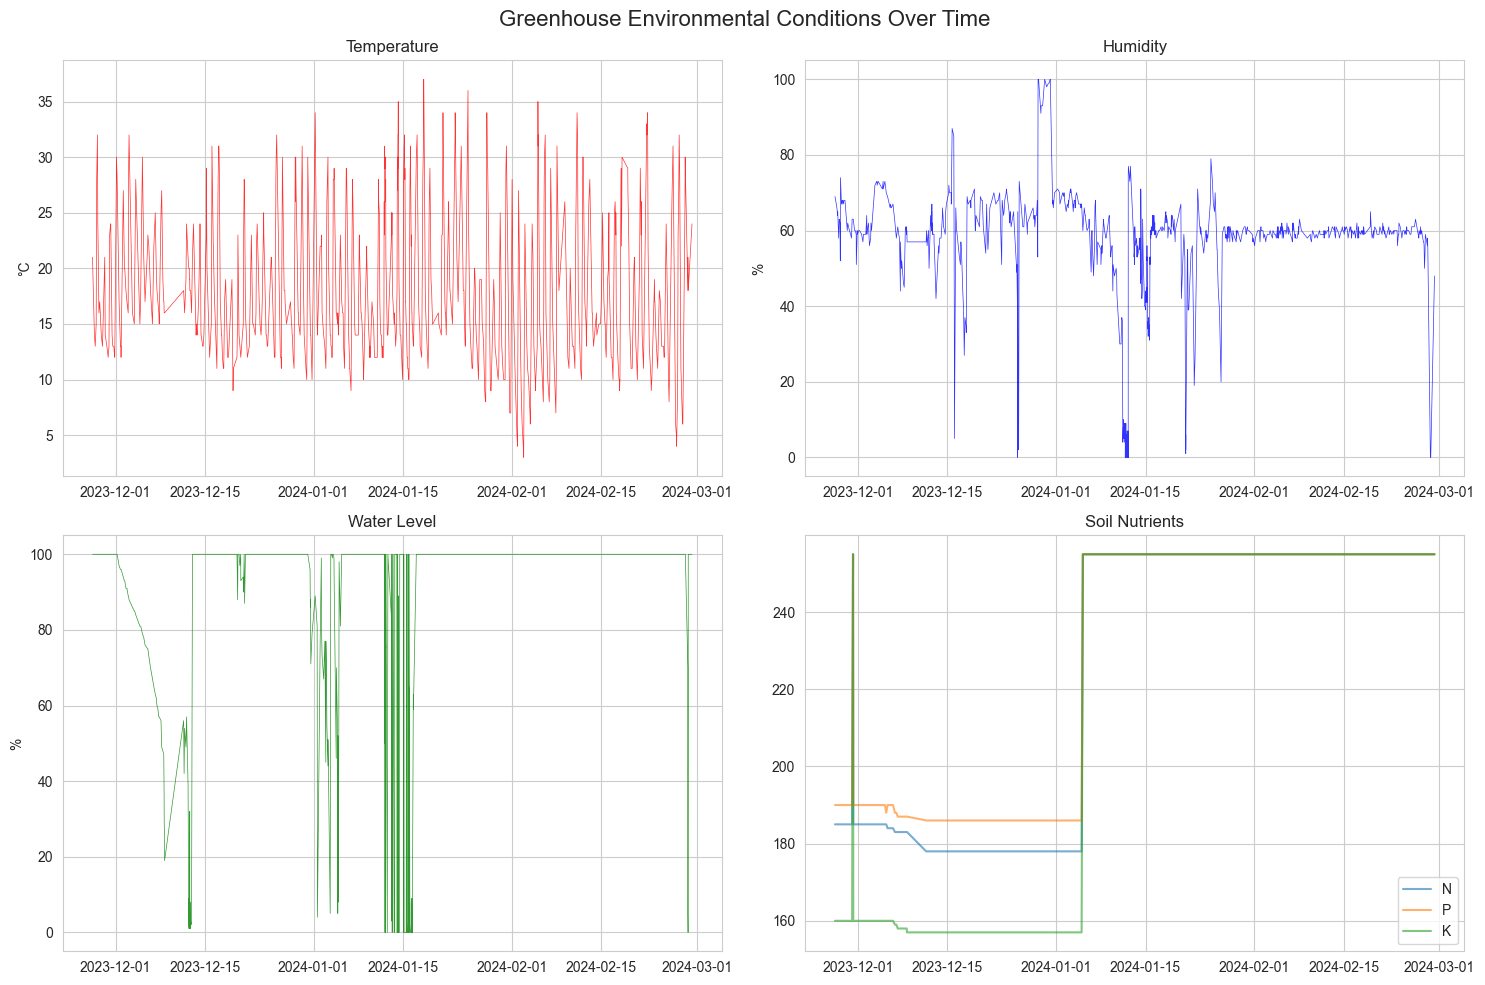

Generare matrice de corelație...


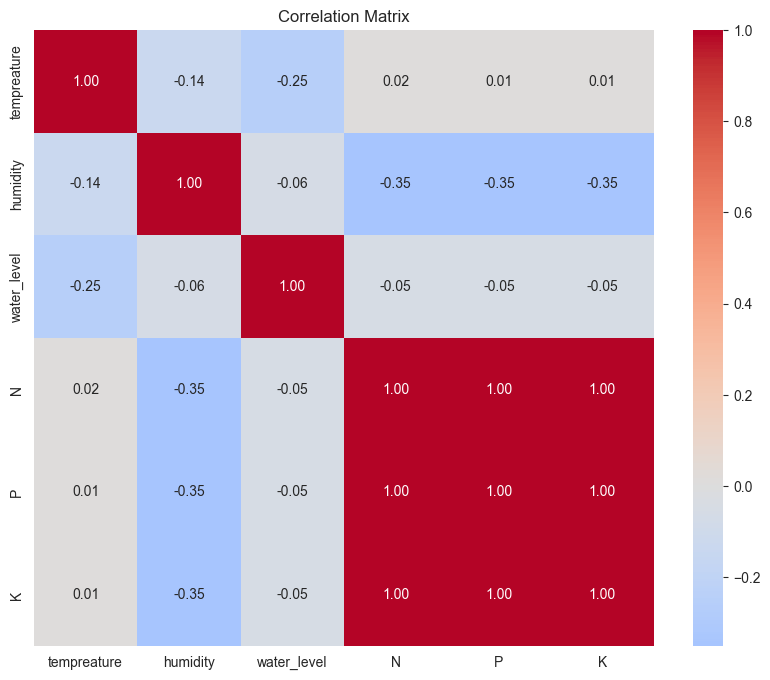

In [5]:
raw_data = load_data()
if raw_data is not None:
    vis = GreenhouseVisualizer()
    print("Generare grafice serii de timp (eșantion 1000 înregistrări)...")
    vis.plot_environmental_timeseries(raw_data.sample(min(1000, len(raw_data))).sort_index())
    
    print("Generare matrice de corelație...")
    vis.plot_correlation_matrix(raw_data)

In [6]:
class GreenhousePredictionModels:
    def __init__(self):
        self.models = {}
        self.metrics = {}
        
    def _evaluate_model(self, y_train, y_pred_train, y_test, y_pred_test, target_name):
        return {
            'target': target_name,
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
            'test_r2': r2_score(y_test, y_pred_test)
        }

    def train_linear_regression(self, X_train, y_train, X_test, y_test, target_name='temperature'):
        print(f"Training Linear Regression for {target_name}...")
        model = LinearRegression()
        model.fit(X_train, y_train)
        
        metrics = self._evaluate_model(
            y_train, model.predict(X_train),
            y_test, model.predict(X_test), target_name
        )
        
        key = f'linear_{target_name}'
        self.models[key] = model
        self.metrics[key] = metrics
        return model, metrics

    def train_random_forest(self, X_train, y_train, X_test, y_test, target_name='water_level'):
        print(f"Training Random Forest for {target_name}...")
        model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        
        metrics = self._evaluate_model(
            y_train, model.predict(X_train),
            y_test, model.predict(X_test), target_name
        )
        
        key = f'rf_{target_name}'
        self.models[key] = model
        self.metrics[key] = metrics
        return model, metrics

In [7]:
class ResourceOptimizer:
    def __init__(self):
        self.optimization_history = []
        
    def calculate_optimal_water_usage(self, current_water_level, soil_nutrients, temperature, humidity):

        OPTIMAL_WATER_LEVEL = 85
        OPTIMAL_TEMP = 32
        OPTIMAL_HUMIDITY = 60

        temp_factor = 1.0
        if temperature > OPTIMAL_TEMP:
            temp_factor = 1.0 + (temperature - OPTIMAL_TEMP) * 0.02
        elif temperature < OPTIMAL_TEMP:
            temp_factor = 1.0 - (OPTIMAL_TEMP - temperature) * 0.01
            

        humidity_factor = 1.0
        if humidity < OPTIMAL_HUMIDITY:
            humidity_factor = 1.0 + (OPTIMAL_HUMIDITY - humidity) * 0.01

        avg_nutrients = (soil_nutrients['N'] + soil_nutrients['P'] + soil_nutrients['K']) / 3
        nutrient_factor = 1.0 - (avg_nutrients / 255) * 0.1
        

        adjusted_optimal = OPTIMAL_WATER_LEVEL * temp_factor * humidity_factor * nutrient_factor
        adjusted_optimal = min(100, max(0, adjusted_optimal)) # Clamp 0-100
        

        water_needed = max(0, adjusted_optimal - current_water_level)

        waste_factor = abs(current_water_level - adjusted_optimal) / 100
        efficiency_score = (1 - waste_factor) * 100
        

        optimization = {
            'current_water_level': current_water_level,
            'optimal_water_level': round(adjusted_optimal, 2),
            'water_needed': round(water_needed, 2),
            'efficiency_score': round(efficiency_score, 2),
            'factors': {
                'temperature': round(temp_factor, 3),
                'humidity': round(humidity_factor, 3),
                'nutrients': round(nutrient_factor, 3)
            }
        }
        
        self.optimization_history.append(optimization)
        return optimization

    def generate_report(self):
        if not self.optimization_history: return "No data."
        df = pd.DataFrame(self.optimization_history)
        return f"Raport: Eficiență medie {df['efficiency_score'].mean():.2f}/100"

In [8]:
class ActuatorController:
    def __init__(self):
        self.TEMP_MAX = 36
        self.HUMIDITY_MAX = 75
        self.WATER_MIN = 70
        
    def control_all_actuators(self, temperature, humidity, water_level):
        decisions = {}
        
        # Fan Control
        if temperature > self.TEMP_MAX or humidity > self.HUMIDITY_MAX:
            decisions['Fan'] = {'state': 'ON', 'reason': 'Temp/Hum High'}
        else:
            decisions['Fan'] = {'state': 'OFF', 'reason': 'Optimal'}
            
        #  Water Pump Control
        if water_level < self.WATER_MIN:
            decisions['Pump'] = {'state': 'ON', 'reason': 'Water Low'}
        else:
            decisions['Pump'] = {'state': 'OFF', 'reason': 'Water Sufficient'}
            
        return decisions

## 2. Antrenarea Modelelor și Evaluare
În această etapă, datele sunt preprocesate și utilizate pentru a antrena algoritmi de predicție.

Start Preprocessing...
Loading dataset from archive 1/IoTProcessed_Data.csv...
Dataset loaded: 37922 records, 13 columns
Applying signal denoising with window size 5...
Found 2 missing values. Applying imputation...
Training Linear Regression for temperature...
Training Random Forest for water_level...

Rezultate:
linear_temperature: RMSE Test = 0.0000, R2 = 1.0000
rf_water_level: RMSE Test = 0.0015, R2 = 1.0000


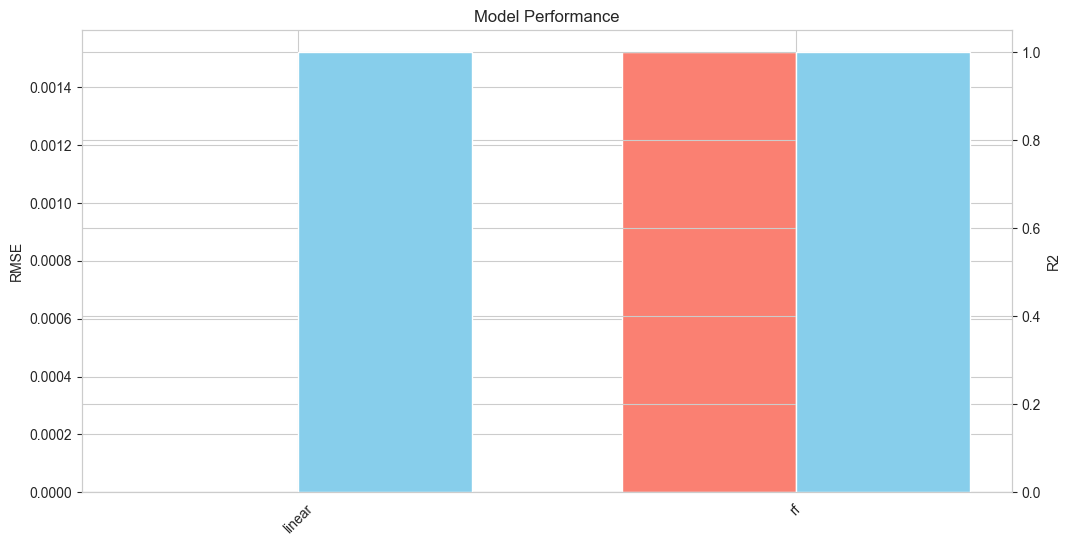

In [9]:
print("Start Preprocessing...")
X_train, X_test, y_train, y_test, prep = load_and_preprocess_data(apply_pca_flag=False)

if X_train is not None:
    gm = GreenhousePredictionModels()
    gm.train_linear_regression(X_train, y_train['temperature'], X_test, y_test['temperature'], 'temperature')
    gm.train_random_forest(X_train, y_train['water_level'], X_test, y_test['water_level'], 'water_level')
    
    print("\nRezultate:")
    for k, v in gm.metrics.items():
        print(f"{k}: RMSE Test = {v['test_rmse']:.4f}, R2 = {v['test_r2']:.4f}")
        
    vis = GreenhouseVisualizer()
    vis.plot_model_performance(gm.metrics)

## 3. Demonstrație Sistem Inteligent (Optimizare & Control)
Simulăm câteva scenarii pentru a testa logica de decizie a serei.

1. DEMONSTRAȚIE LOGICĂ DE DECIZIE

Scenariu: Zi Caniculară (T=38C, H=40%, Water=60%)
  [Optimizator] Apă necesară: 40% (Factor Temp: 1.12)
  [Actuator]  Fan: ON (Temp/Hum High)
  [Actuator]  Pump: ON (Water Low)

Scenariu: Condiții Normale (T=28C, H=60%, Water=80%)
  [Optimizator] Apă necesară: 0% (Factor Temp: 0.96)
  [Actuator]  Fan: OFF (Optimal)
  [Actuator]  Pump: OFF (Water Sufficient)


2. ANALIZĂ DE OPTIMIZARE PE TERMEN LUNG (Simulare 100 evenimente)
Se generează date randomizate pentru a popula graficele de performanță...
Simulare completă. Se generează raportul grafic...


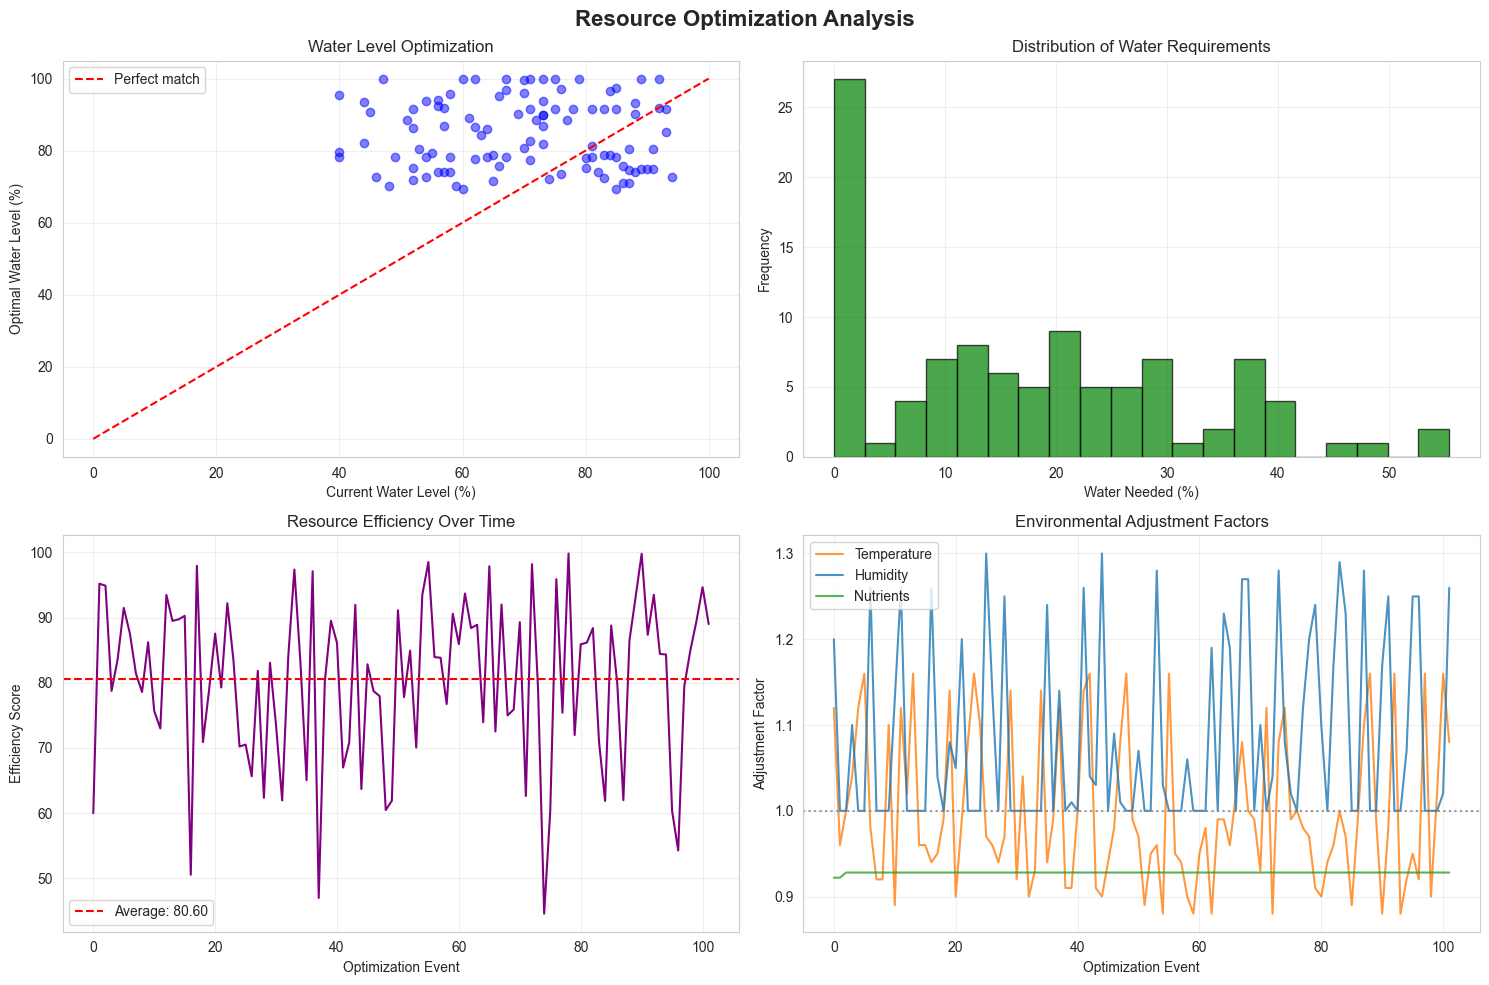

In [10]:
import random

optimizer = ResourceOptimizer()
controller = ActuatorController()
vis = GreenhouseVisualizer()

#  Scenarii Text 
scenarios = [
    {'name': 'Zi Caniculară', 'temp': 38, 'hum': 40, 'water': 60, 'nutrients': {'N':200, 'P':200, 'K':200}},
    {'name': 'Condiții Normale', 'temp': 28, 'hum': 60, 'water': 80, 'nutrients': {'N':200, 'P':200, 'K':200}},
]

print("1. DEMONSTRAȚIE LOGICĂ DE DECIZIE")
for sc in scenarios:
    print(f"\nScenariu: {sc['name']} (T={sc['temp']}C, H={sc['hum']}%, Water={sc['water']}%)")
    
    opt_res = optimizer.calculate_optimal_water_usage(sc['water'], sc['nutrients'], sc['temp'], sc['hum'])
    
    water_needed = opt_res['water_needed']
    temp_factor = opt_res['factors']['temperature']
    
    print(f"  [Optimizator] Apă necesară: {water_needed}% (Factor Temp: {temp_factor})")
    
    act_res = controller.control_all_actuators(sc['temp'], sc['hum'], sc['water'])
    for act, status in act_res.items():
        print(f"  [Actuator]  {act}: {status['state']} ({status['reason']})")

#  Simulare Batch 
print("\n")
print("2. ANALIZĂ DE OPTIMIZARE PE TERMEN LUNG (Simulare 100 evenimente)")
print("Se generează date randomizate pentru a popula graficele de performanță...")

for i in range(100):
    optimizer.calculate_optimal_water_usage(
        current_water_level=random.randint(40, 95), # Nivel aleatoriu apă
        soil_nutrients={'N': 200, 'P': 190, 'K': 160},
        temperature=random.randint(20, 40), # ATENȚIE: parametrul este 'temperature' nu 'temp' în varianta complexă
        humidity=random.randint(30, 90) 
    )

print("Simulare completă. Se generează raportul grafic...")

vis.plot_resource_savings(optimizer.optimization_history)